In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% ! important;}
div.cell.code_cell.rendered{width:100%}
div.input_prompt{padding:0px}
div.CodeMirror {font-family:Consolas ; font-size:12pt;}
div.text_cell_render.rendered_html {font-size:12pt;}
div.output {font-size:12pt; font-weight:bold}
div.input {font-family:Consolas ; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper {padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

<b><font size="6" color="red">ch.02 한글 자연어처리 패키지</font></b>
# 1. 자연어 처리
- 자연어 : 일상적인 언어
- 자연어 처리 분석
    * 자연어 이해 : 형태소 분석 -> pos tagging(품사태깅) -> 의미분석(빈도분석, 연관분석) -> RNN
    * 자연어 이해&선성 : RNN/LSTM/GRU -> seq2seq -> 트랜스포머
- 활용분야 : 트랜드 분석, 탐색적 분석, 맞춤법 검사, 번역기, 챗봇
# 2. 자연어 이해/ 생성 처리 절차
- 전처리 : 단어/ 어절 추출 (특수문자 ㅎㅎ 제외)
- 분석 후보 생성 : 형태소 분리, 품사 태깅
- 제약 조건 : 불용어 처리, 규칙 확인
- 분석 : 시각화(워드클라우드, Text), 유사성 분석, 연관분석, RNN/LSTM/GUR, ....
# 3. 형태소 분석 엔진
- Konlpy (pip install konlpy)
    * HanNanum : java로 만든 형태소 분석기(JAVA_HOME환경변수, Path설정)
    * Kkma     : 위와 동일
    * Komoran  : 위와 동일
    * Okt      : 위와 동일
- Mecab (pip install pypthon-mecab-ko)
    * Mecab : c++로 만든 형태소 분석기. 저사양 환경에서 사용 가능
- 공통기능 : morphs(형태소 나누기), nonus(명사추출), pos(형태소로 나누어 품사태그)

- pos tagging chat 다운로드
    * 구글서 konlp docs -> https://konlpy.org/en/latest/index.html 
    * API 메뉴 -> Comparison between POS tagging classes 클릭 -> 
    * Korean POS tags comparison chart 다운로드

In [8]:
%pip show konlpy

Name: konlpy
Version: 0.6.0
Summary: Python package for Korean natural language processing.
Home-page: http://konlpy.org
Author: Team KoNLPy
Author-email: konlpy@googlegroups.com
License: GPL v3
Location: c:\users\admin\anaconda3\envs\ml-dl-nlp\lib\site-packages
Requires: JPype1, lxml, numpy
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [6]:
%pip show python-mecab-ko

Name: python-mecab-ko
Version: 1.3.7
Summary: A python binding for mecab-ko
Home-page: https://github.com/jonghwanhyeon/python-mecab-ko
Author: Jonghwan Hyeon
Author-email: jonghwanhyeon93@gmail.com
License: BSD 3-Clause License
Location: c:\users\admin\anaconda3\envs\ml-dl-nlp\lib\site-packages
Requires: python-mecab-ko-dic
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [7]:
%pip show wordcloud

Name: wordcloud
Version: 1.9.4
Summary: A little word cloud generator
Home-page: https://github.com/amueller/word_cloud
Author: 
Author-email: Andreas Mueller <t3kcit+wordcloud@gmail.com>
License: MIT License
Location: c:\users\admin\anaconda3\envs\ml-dl-nlp\lib\site-packages
Requires: matplotlib, numpy, pillow
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [10]:
%pip show gensim

Name: gensim
Version: 4.4.0
Summary: Python framework for fast Vector Space Modelling
Home-page: https://radimrehurek.com/gensim/
Author: Radim Rehurek
Author-email: me@radimrehurek.com
License: LGPL-2.1-only
Location: c:\users\admin\anaconda3\envs\ml-dl-nlp\lib\site-packages
Requires: numpy, scipy, smart_open
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [20]:
import os
os.environ.get('JAVA_HOME')

'C:\\Program Files\\Java\\jdk-17'

In [21]:
import konlpy
konlpy.__version__ # 에러나는 경우 jpypel라이브러리를 수동 설치(현 버전에서는 설치x)

'0.6.0'

In [22]:
text = '''아름답지만 다소 복잡하기도 한 한국어는 전세계에서 13번째로 많이 사용되는 언어입니다.'''

## 3.1 HanNanum

In [23]:
from konlpy.tag import Hannanum
hannanum = Hannanum(jvmpath=None) # 기본값:1024 '1gb' '10m'
# 입력된 텍스트를 가장 세밀하게 분석해서 형태소, 품사, 원형등을 모두 반환
hannanum.analyze(text)

[[[('아름답', 'paa'), ('지만', 'ecs')],
  [('아름답', 'paa'), ('지', 'ecs'), ('만', 'jxc')],
  [('아름답', 'paa'), ('지', 'ecx'), ('말', 'px'), ('ㄴ', 'etm')]],
 [[('다소', 'mag')], [('다소', 'ncn')]],
 [[('복잡', 'ncn'), ('하기', 'ncn'), ('도', 'jxc')],
  [('복잡', 'ncn'), ('하기', 'ncn'), ('도', 'ncn')],
  [('복잡', 'ncps'), ('하기', 'ncn'), ('도', 'jxc')],
  [('복잡', 'ncps'), ('하기', 'ncn'), ('도', 'ncn')],
  [('복잡', 'ncps'), ('하', 'xsms'), ('기', 'etn'), ('도', 'jxc')]],
 [[('하', 'pvg'), ('ㄴ', 'etm')],
  [('한', 'nnc')],
  [('한', 'ncn')],
  [('한', 'nbn')],
  [('하', 'px'), ('ㄴ', 'etm')]],
 [[('한국어', 'ncn'), ('는', 'jxc')]],
 [[('전세계', 'ncn'), ('에서', 'jca')],
  [('전세', 'ncn'), ('계', 'ncn'), ('에서', 'jca')],
  [('전', 'xp'), ('세계', 'ncn'), ('에서', 'jca')]],
 [[('13', 'nnc'), ('번', 'nbu'), ('째', 'xsnu'), ('로', 'jca')]],
 [[('많', 'paa'), ('이', 'xsa')], [('많이', 'mag')]],
 [[('사용', 'ncpa'), ('되', 'xsvn'), ('는', 'etm')]],
 [[('언어', 'ncn'), ('이', 'jp'), ('ㅂ니다', 'ef')]],
 [[('.', 'sf')], [('.', 'sy')]]]

In [5]:
# 형태소 분석 : morphs
print(hannanum.morphs(text))

['아름답', '지만', '다소', '복잡', '하', '기', '도', '하', 'ㄴ', '한국어', '는', '전세계', '에서', '13번', '째', '로', '많', '이', '사용', '되', '는', '언어', '이', 'ㅂ니다', '.']


In [6]:
# 명사만 추출 : nouns
print(hannanum.nouns(text))

['복잡', '한국어', '전세계', '13번', '사용', '언어']


In [7]:
# 품사추출 : pos
print(hannanum.pos(text, ntags=22)) # 품사 갯수 기본값 9

[('아름답', 'PA'), ('지만', 'EC'), ('다소', 'MA'), ('복잡', 'NC'), ('하', 'XS'), ('기', 'ET'), ('도', 'JX'), ('하', 'PV'), ('ㄴ', 'ET'), ('한국어', 'NC'), ('는', 'JX'), ('전세계', 'NC'), ('에서', 'JC'), ('13', 'NN'), ('번', 'NB'), ('째', 'XS'), ('로', 'JC'), ('많', 'PA'), ('이', 'XS'), ('사용', 'NC'), ('되', 'XS'), ('는', 'ET'), ('언어', 'NC'), ('이', 'JP'), ('ㅂ니다', 'EF'), ('.', 'SF')]


In [8]:
# 퀴즈 1 pos tag 결과에서 명사(NC, NQ, NB, NN)만 추출하기
tagged_text = hannanum.pos(text, ntags = 22)
[token for token, tag in tagged_text if tag in ('NC', 'NQ', 'NB', 'NN')]

['복잡', '한국어', '전세계', '13', '번', '사용', '언어']

In [9]:
# 퀴즈 2 text에서 보통명사(NC)만 추출하기
[token for token, tag in tagged_text if tag == 'NC']

['복잡', '한국어', '전세계', '사용', '언어']

In [10]:
# 퀴즈 3 text에서 형용사(PA)만 추출하기
[token for token, tag in tagged_text if tag == 'PA']

['아름답', '많']

## 3.2 Kkma

In [11]:
from konlpy.tag import Kkma
kkma = Kkma()
# 형태소 추출
print(kkma.morphs(text))

['아름답', '지만', '다소', '복잡', '하', '기', '도', '한', '한국어', '는', '전세계', '에서', '13', '번째', '로', '많이', '사용', '되', '는', '언어', '이', 'ㅂ니다', '.']


In [12]:
# 명사추출
print(kkma.nouns(text))

['복잡', '한국어', '전세계', '13', '13번째', '번째', '사용', '언어']


In [13]:
# 품사태그
print(kkma.pos(text))

[('아름답', 'VA'), ('지만', 'ECE'), ('다소', 'MAG'), ('복잡', 'NNG'), ('하', 'XSV'), ('기', 'ETN'), ('도', 'JX'), ('한', 'MDN'), ('한국어', 'NNG'), ('는', 'JX'), ('전세계', 'NNG'), ('에서', 'JKM'), ('13', 'NR'), ('번째', 'NNB'), ('로', 'JKM'), ('많이', 'MAG'), ('사용', 'NNG'), ('되', 'XSV'), ('는', 'ETD'), ('언어', 'NNG'), ('이', 'VCP'), ('ㅂ니다', 'EFN'), ('.', 'SF')]


In [15]:
# 품사태그를 통해 명사(NNG, NNB, NNP, NNM, NR, NP)만 추출
tagged_text = kkma.pos(text)
[token for  token, tag in tagged_text if tag in ('NNG', 'NNB', 'NNP', 'NNM', 'NR', 'NP')]

['복잡', '한국어', '전세계', '13', '번째', '사용', '언어']

In [16]:
# 품사태그를 통해 보통명사(NNG)만 추출
[token for token, tag in tagged_text if tag == 'NNG']

['복잡', '한국어', '전세계', '사용', '언어']

## 3.3 Komoran

In [24]:
from konlpy.tag import Komoran
komoran = Komoran()
print(komoran.morphs(text))

['아름답', '지만', '다소', '복잡', '하', '기', '도', '한', '한국어', '는', '전', '세계', '에서', '13', '번', '째', '로', '많이', '사용', '되', '는', '언어', '이', 'ㅂ니다', '.']


In [25]:
# 명사추출
print(komoran.nouns(text))

['한국어', '전', '세계', '번', '사용', '언어']


In [26]:
# 품사 추출
tagged_text = komoran.pos(text)
print(tagged_text)

[('아름답', 'VA'), ('지만', 'EC'), ('다소', 'MAG'), ('복잡', 'XR'), ('하', 'XSA'), ('기', 'ETN'), ('도', 'JX'), ('한', 'MM'), ('한국어', 'NNP'), ('는', 'JX'), ('전', 'NNG'), ('세계', 'NNG'), ('에서', 'JKB'), ('13', 'SN'), ('번', 'NNB'), ('째', 'XSN'), ('로', 'JKB'), ('많이', 'MAG'), ('사용', 'NNG'), ('되', 'XSV'), ('는', 'ETM'), ('언어', 'NNG'), ('이', 'VCP'), ('ㅂ니다', 'EF'), ('.', 'SF')]


In [27]:
# 품사태그를 이용해서 명사(NNG, NNP, NNB, NR, NP)만 추출
[token for token, tag in tagged_text if tag in ('NNG', 'NNP', 'NNB', 'NR', 'NP')]

['한국어', '전', '세계', '번', '사용', '언어']

## 3.4 Twitter(Okt : Open Korean Text)
- SNS 텍스트 분석용 개발

In [31]:
from konlpy.tag import Okt, Twitter
# okt = Twiiter()
okt = Okt()
# print('명사구 추출 :', okt.phrases(text))
print('형태소 추출 :', okt.morphs(text))
print('명사 추출 :', okt.nouns(text))
tagged_text = okt.pos(text)
print('품사 태깅을 이용한 명사 추출 :',
     [token for token, tag in tagged_text if tag=='Noun']
     )
print('품사 태깅 :', tagged_text)

형태소 추출 : ['아름답지만', '다소', '복잡하기도', '한', '한국어', '는', '전세계', '에서', '13', '번', '째', '로', '많이', '사용', '되는', '언어', '입니다', '.']
명사 추출 : ['다소', '한국어', '전세계', '번', '사용', '언어']
품사 태깅을 이용한 명사 추출 : ['다소', '한국어', '전세계', '번', '사용', '언어']
품사 태깅 : [('아름답지만', 'Adjective'), ('다소', 'Noun'), ('복잡하기도', 'Adjective'), ('한', 'Verb'), ('한국어', 'Noun'), ('는', 'Josa'), ('전세계', 'Noun'), ('에서', 'Josa'), ('13', 'Number'), ('번', 'Noun'), ('째', 'Suffix'), ('로', 'Josa'), ('많이', 'Adverb'), ('사용', 'Noun'), ('되는', 'Verb'), ('언어', 'Noun'), ('입니다', 'Adjective'), ('.', 'Punctuation')]


## 3.5 Mecab
- pip install pypthon_mecab
- 압도적 속ㄷ(konlpy 대비 약 5~15배 빠름
- 낮은 메모리 사용량
- 형태소 분해 정확도 높음

In [33]:
from mecab import MeCab
# okt = Twiiter()
mecab = MeCab()
print('형태소 추출 :', mecab.morphs(text))
print('명사 추출 :', mecab.nouns(text))
tagged_text = mecab.pos(text)
print('품사 태깅을 이용한 명사 추출 :',
     [token for token, tag in tagged_text if tag in ('NNG','NNP', 'NNB', 'NNBC')]
     )
print('품사 태깅 :', tagged_text)

형태소 추출 : ['아름답', '지만', '다소', '복잡', '하', '기', '도', '한', '한국어', '는', '전', '세계', '에서', '13', '번', '째', '로', '많이', '사용', '되', '는', '언어', '입니다', '.']
명사 추출 : ['한국어', '세계', '번', '사용', '언어']
품사 태깅을 이용한 명사 추출 : ['한국어', '세계', '번', '사용', '언어']
품사 태깅 : [('아름답', 'VA'), ('지만', 'EC'), ('다소', 'MAG'), ('복잡', 'XR'), ('하', 'XSA'), ('기', 'ETN'), ('도', 'JX'), ('한', 'MM'), ('한국어', 'NNG'), ('는', 'JX'), ('전', 'MM'), ('세계', 'NNG'), ('에서', 'JKB'), ('13', 'SN'), ('번', 'NNBC'), ('째', 'XSN'), ('로', 'JKB'), ('많이', 'MAG'), ('사용', 'NNG'), ('되', 'XSV'), ('는', 'ETM'), ('언어', 'NNG'), ('입니다', 'VCP+EF'), ('.', 'SF')]


# 4. 말 뭉치

In [36]:
# 영어말뭉치
import nltk
emma = nltk.corpus.gutenberg.raw('austen-emma.txt')

In [37]:
emma[:10]

'[Emma by J'

In [40]:
# 한글 말뭉치
from konlpy.corpus import kolaw
# data = kolaw.open('constitution.txt').readlines() # 한줄씩 list로 반환
data = kolaw.open('constitution.txt').read()
print('글자수 : ', len(data))

글자수 :  18884


# 5. 워드 클라우드
- pip install wordcloud

In [43]:
nouns = ['word1', 'word2', 'word1', 'word2']
' '.join(nouns)

'word1 word2 word1 word2'

In [49]:
# emma 말뭉치에서 단어 추출하고 (특수문자 제외) -> 명사(NN, NNS, NNP, NNPS) 추출 -> 연결 -> 워드 클라우드
from nltk.tokenize import RegexpTokenizer
from nltk.tag import pos_tag
ret=RegexpTokenizer('[0-9a-zA-Z]{2,}')
words = ret.tokenize(emma)
words[:3]
# pos tagging -> 명사 추출
emma_tags = pos_tag(words)
noun_list = [token for token, tag in emma_tags if tag in ('NN', 'NNS', 'NNP', 'NNPS')]
# 연결
emma_noun = ' '.join(noun_list)
print('워드 클라우드를 그릴 text 내용 :', emma_noun[:20])

워드 클라우드를 그릴 text 내용 : Emma Jane Austen VOL


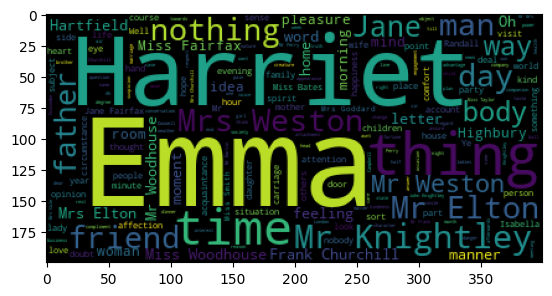

In [50]:
# 워드 클라우드 작성
from wordcloud import WordCloud
from matplotlib import pyplot as plt
wordc = WordCloud()
wordc.generate(emma_noun)
plt.imshow(wordc)
plt.show()

- 컬러맵 : https://matplotlib.org/stable/users/explain/colors/colormaps.html

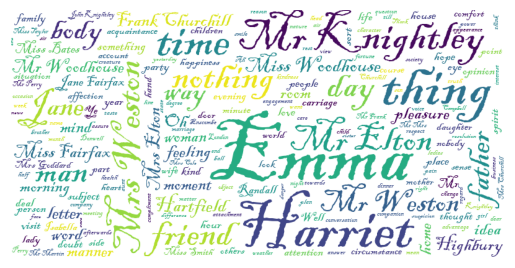

In [66]:
wordcloud = WordCloud(
    font_path = 'C:/Windows/Fonts/ITCBLKAD.TTF',
    background_color= 'white',
    width=800, height=400, # 생성될 이미지 가로 세로(픽셀)
    max_words=300, # 최대 표시될 단어 갯수
    relative_scaling = 0.6, # 단어 빈도에 따른 크기차이 조정
    colormap= 'viridis', # 글씨 컬러맵
    max_font_size = 150, # 최대 폰트 사이즈
    min_font_size = 10, # 최소 폰트 사이즈
    random_state = 30
)
wordcloud.generate(emma_noun)
# plt.figure(figsize=(20,7))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [75]:
# data에서 명사추출 -> 빈도수 파악
from konlpy.tag import Hannanum, Kkma, Komoran, Okt
from mecab import MeCab
analyzer = MeCab() # mecab, kkma 의 경우 NNG, NNP/ okt의 경우 None
noun_list = analyzer.nouns(data)
noun_list = [word for word, tag in analyzer.pos(data) if tag in ('NNG', 'NNP')]
noun_list[:10]
# data 한글 말뭉치로 워드 count
from nltk import FreqDist
import pandas as pd
noun_wordcount = FreqDist(noun_list)
wordcnt = pd.Series(noun_wordcount)
wordcnt.sort_values(ascending = False, inplace=True)
wordcnt.head(20)

법률     121
대통령     84
조       79
국가      73
헌법      69
국민      69
국회      69
때       55
필요      31
위원      30
기타      26
법원      25
보장      24
정부      23
국무      23
사항      23
항       22
권리      21
자유      21
회의      21
dtype: int64

명사 추출 : ['대한민국', '헌법', '역사', '전통', '국민']
워드클라우드를 그릴 data : 대한민국 헌법 역사 전통 국민 운동 


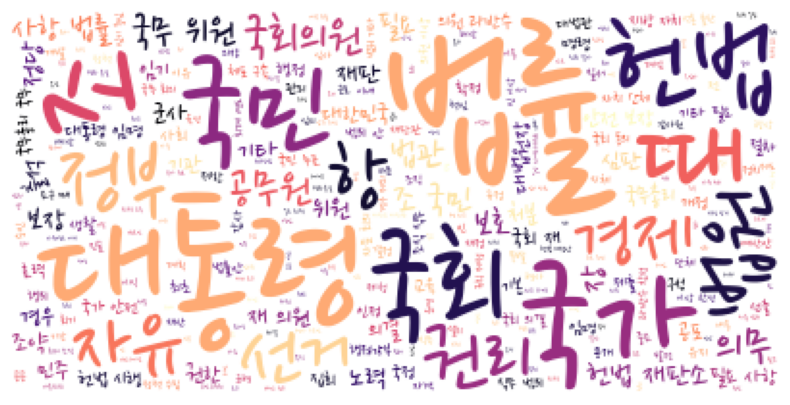

In [83]:
# data에서 명사추출 -> 연결 -> 워드 클라우드
data_noun = " ".join(noun_list)
print('명사 추출 :',noun_list[:5])
print('워드클라우드를 그릴 data :',data_noun[:20])
wordcloud = WordCloud(
    font_path='data/NanumPenScript-Regular.ttf', # 폰트
    background_color='white', # 배경색
    max_words=300, # 표시될 단어의 최대 갯수
    #relative_scaling=0.6 # 단어 빈도에 따른 크기 차이 조정
    colormap= 'magma', # 글씨 컬러맵
)
wordcloud.generate(data_noun)
plt.figure(figsize=(18,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [86]:
# 불용어(불용어지정 + 불용어사전)
from wordcloud import STOPWORDS
# STOPWORDS # 불용어사전(한글 X), set
불용어 = STOPWORDS | {'대통령', '조', '때', '항'} # stopwords가 존재하여 한글 불용어 변수는 주로 한글로 쓴다. | : 집합 합 연산자
불용어 = {'대통령', '조', '때', '항'}
불용어

{'대통령', '때', '조', '항'}

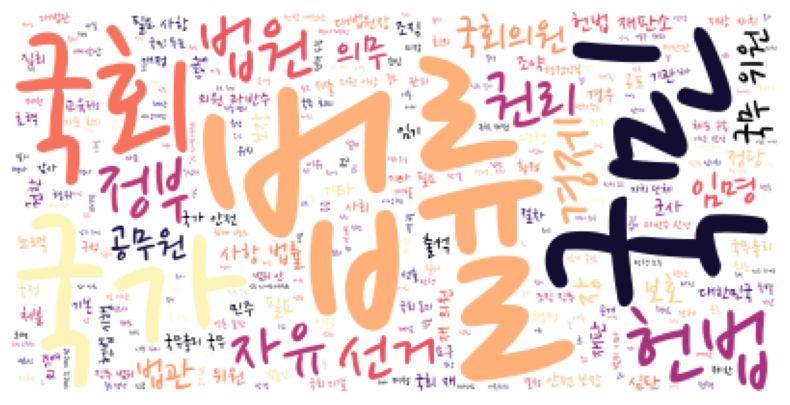

In [87]:
wordcloud = WordCloud(
    font_path='data/NanumPenScript-Regular.ttf', # 폰트
    background_color='white', # 배경색
    max_words=300, # 표시될 단어의 최대 갯수
    #relative_scaling=0.6 # 단어 빈도에 따른 크기 차이 조정
    colormap= 'magma', # 글씨 컬러맵
    stopwords= 불용어
)
wordcloud.generate(data_noun)
plt.figure(figsize=(18,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

(numpy.ndarray, (468, 720, 3))

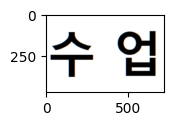

In [90]:
# 이미지를 넘파이배열로(방법1)
import cv2
mask = cv2.imread('data/test.png')
plt.figure(figsize=(2,1))
plt.imshow(mask)
type(mask), mask.shape # 3채널 이미지

(numpy.ndarray, (468, 720, 3))

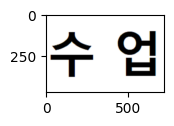

In [93]:
# 이미지를 넘파이배열로(방법2)
from PIL import Image
import numpy as np
img = Image.open('data/test.png')
mask = np.array(img)
plt.figure(figsize=(2,1))
plt.imshow(mask)
type(mask), mask.shape

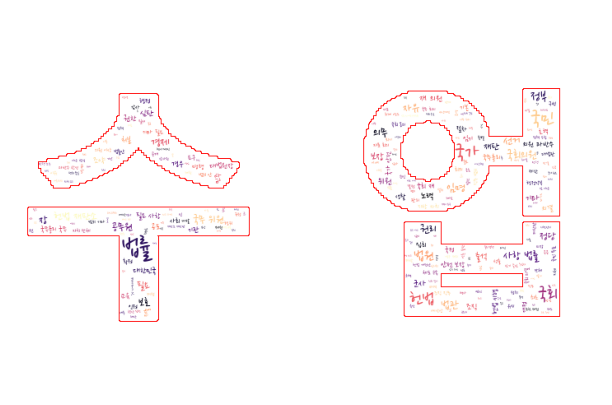

In [99]:
wordcloud = WordCloud(
    font_path='data/NanumPenScript-Regular.ttf', # 폰트
    background_color='white', # 배경색
    max_words=300, # 표시될 단어의 최대 갯수
    #relative_scaling=0.6 # 단어 빈도에 따른 크기 차이 조정
    colormap= 'magma', # 글씨 컬러맵
    stopwords= 불용어,
    mask=mask,
    contour_color='red',
    contour_width=1
)
wordcloud.generate(data_noun)
plt.figure(figsize=(18,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

(numpy.ndarray, (1600, 1600))

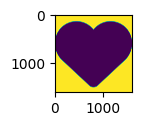

In [122]:
# mask = cv2.imread('data/heart.jpg')
img = Image.open('data/heart.jpg')
mask = np.array(img)
plt.figure(figsize=(2,1))
plt.imshow(mask)
type(mask), mask.shape # 흑백이미지

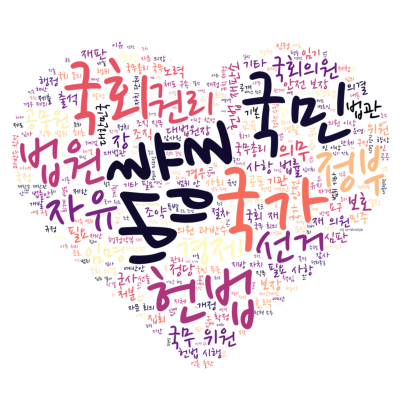

In [104]:
wordcloud = WordCloud(
    font_path='data/NanumPenScript-Regular.ttf', # 폰트
    background_color='white', # 배경색
    max_words=300, # 표시될 단어의 최대 갯수
    #relative_scaling=0.6 # 단어 빈도에 따른 크기 차이 조정
    colormap= 'magma', # 글씨 컬러맵
    stopwords= 불용어,
    mask=mask,
#     contour_color='red',
#     contour_width=1
)
wordcloud.generate(data_noun)
plt.figure(figsize=(18,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

(numpy.ndarray, (241, 257, 3))

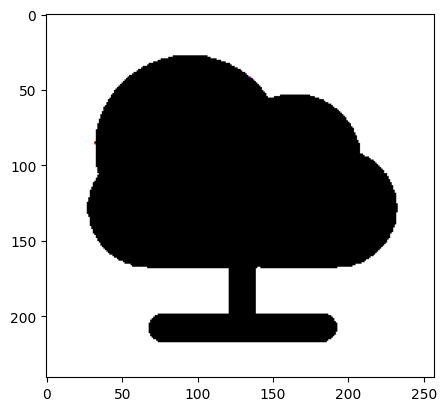

In [126]:
# 이미지 전처리 : 옅은 회색 -> 햐얀색
img = Image.open('data/test2.jpg')
mask = np.array(img)
mask = np.where(mask>200, 255, 0)

plt.figure(figsize=(5,5))
plt.imshow(mask)
type(mask), mask.shape # 3 채널 컬러

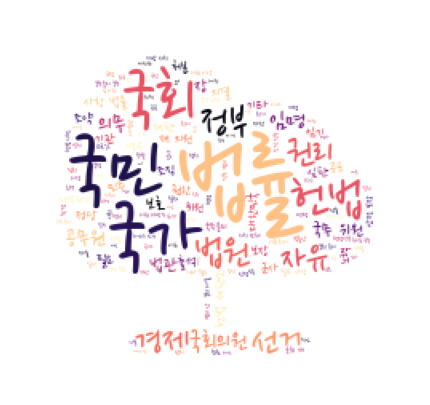

In [127]:
wordcloud = WordCloud(
    font_path='data/NanumPenScript-Regular.ttf', # 폰트
    background_color='white', # 배경색
    max_words=300, # 표시될 단어의 최대 갯수
    #relative_scaling=0.6 # 단어 빈도에 따른 크기 차이 조정
    colormap= 'magma', # 글씨 컬러맵
    stopwords= 불용어,
    mask=mask,
#     contour_color='red',
#     contour_width=1
)
wordcloud.generate(data_noun)
plt.figure(figsize=(18,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

mask 데이터 하나하나의 타입 : uint8
mask 데이터 하나하나의 타입 : uint8
(241, 257, 3)


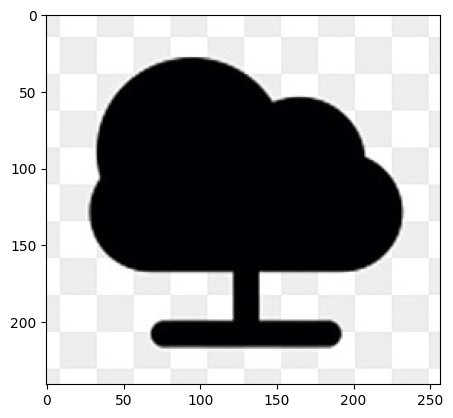

In [125]:
# 이미지 전처리 : 옅은 회색 -> 햐얀색
mask = cv2.imread('data/test2.jpg')
print('mask 데이터 하나하나의 타입 :', mask.dtype) # unit8
mask2 = np.where(mask > 200, 255, 0).astype(np.uint8)
print('mask 데이터 하나하나의 타입 :', mask.dtype) # int32
plt.imshow(mask)
print(mask.shape)

In [133]:
# mask = cv2.imread('data/south_korea.png')
# plt.imshow(mask)
# print(mask.shape)

(1124, 720, 3)


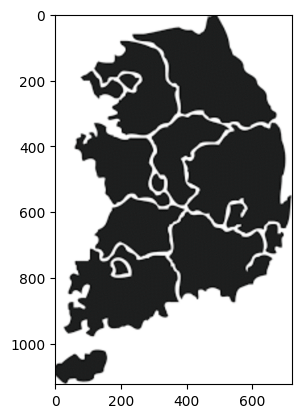

In [131]:
# 1채널 이미지 - > 3채널 : convert('RGB')
img = Image.open('data/south_korea.png').convert('RGB')
mask = np.array(img)
plt.imshow(mask)
print(mask.shape)

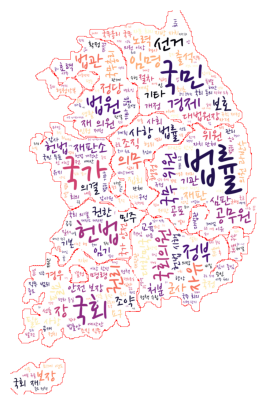

In [135]:
wordcloud = WordCloud(
    font_path='data/NanumPenScript-Regular.ttf', # 폰트
    background_color='white', # 배경색
    max_words=300, # 표시될 단어의 최대 갯수
    #relative_scaling=0.6 # 단어 빈도에 따른 크기 차이 조정
    colormap= 'magma', # 글씨 컬러맵
    stopwords= 불용어,
    mask=mask,
    contour_color='red',
    contour_width=1
)
wordcloud.generate(data_noun)
plt.figure(figsize=(18,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [136]:
# 생성된 wordcloud 저장
wordcloud.to_file('data/korea.jpg')

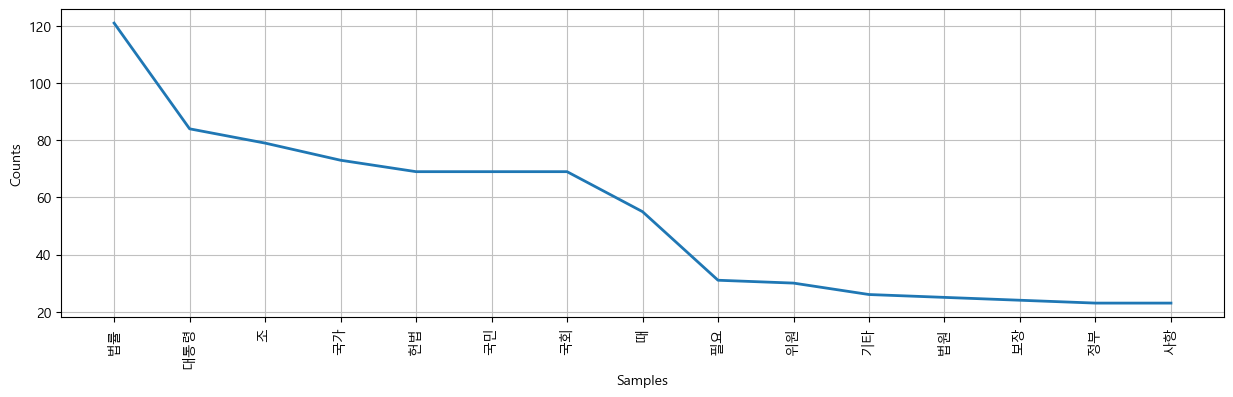

In [137]:
# 단어의 빈도수를 그래프로 시각화(nltk.Text)
import nltk
data_text = nltk.Text(noun_list)
plt.figure(figsize=(15,4))
plt.rc('font', family='Malgun Gothic') # 윈도우즈 한글처리
data_text.plot(15)
plt.show()

# 6. 워드 임베딩
- 단어간 백터 계산 -> 단어간 거리 유사성 도출

In [15]:
import requests
from bs4 import BeautifulSoup
from mecab import MeCab
rss_url = 'https://fs.jtbc.co.kr/RSS/economy.xml'
jtbc_response = requests.get(rss_url)
jtbc_response
soup = BeautifulSoup(jtbc_response.content, 'xml')
item_elems = soup.find_all('item') # item_elems = soup.select('item')
news = []
mecab = MeCab()
for item_elem in item_elems:
    title = item_elem.find('title').text
    description = item_elem.find('description').text
    total_text = title+' '+description
    #noun_list = mecab.nouns(total_text)
    noun_list = [word for word, tag in  mecab.pos(total_text) if tag in ('NNG','NNP')] # 'NNG',' NNP' (보통명사, 고유명사)
    news.append(noun_list)
print(news[:3])

[['전세', '홍수', '예상', '눈치', '게임', '시작', '앵커', '최대', '규모', '재건축', '아파트', '입주', '다음', '달', '시작', '규모', '입주', '전세', '매물', '현장', '분위기'], ['실제', '관리', '소홀', '앵커', '캠', '예약', '때', '예약', '플랫폼', '사진', '실제', '불만', '경우', '앞', '예약', '플랫', '폼', '책임', '강화', '아람', '기자', '기자', '인터넷', '카페'], ['요즘', '편의점', '정도', '앵커', '육박', '점심', '값', '편의점', '도시락', '때', '편의점', '도시락', '식비', '부담', '아람', '기자', '기자']]


In [17]:
# 워드임베딩, Word2Vec(단어간 거리 계산)
# pip install gensim
from gensim.models import Word2Vec
model = Word2Vec(news, # 학습데이터 2차원
                window=10, # 각 단어의 좌우 10개 단어만 학습 컨테츠로 사용
                min_count=2, # 학습데이터에서 2회 이상 등장한 단어만 학습
                workers= -1, # 병렬처리할 코어의 갯수(-1: 모든 코어 사용)    
                sg = 1) # 소량의 데이터일 경우 중심단어로 주변단어를 예측하도로 학습

In [21]:
model.wv.most_similar('가을', topn=5) # topn=10이 기본값

[('편의점', 0.25290459394454956),
 ('메모리', 0.22568336129188538),
 ('대통령', 0.20718970894813538),
 ('때', 0.1781422644853592),
 ('량', 0.1678573042154312)]

In [22]:
# Word2Vec이 학습한 전체단어 어휘집
print(model.wv.index_to_key)

['앵커', '정부', '기자', '경제', '편의점', '도시락', '분기', '결혼', '말', '아람', '지원', '이상', '전어', '가을', '실적', '최고', '비정규직', '올해', '내년', '부부', '예비', '오늘', '예약', '아파트', '지수', '증시', '대출', '상태', '재무', '제철', '폭염', '배', '최근', '가격', '사상', '역대', '비용', '최대', '예상', '연속', '디딤돌', '서민', '전국', '거래', '피해', '확인', '사실', '매출', '업체', '입점', '사업', '직전', '사태', '정산', '미', '위', '책정', '예산', '상황', '갈치', '꽃게', '량', '조업', '탓', '여름', '황금연휴', '추석', '배추', '영향', '메모리', '급', '수출', '어제', '대통령', '기준', '근로자', '임금', '비중', '소식', '결혼식', '현실', '문제', '걱정', '주가', '아연', '고려', '롤러코스터', '값', '정도', '앞', '때', '실제', '입주', '규모', '시작', '전세']


In [24]:
# 유사한 단어를 출력
print('입력한 다어와 유사한 단어 10개를 출력합니다.')
key = input()
if key in model.wv:
    print('{}와 유사한 단어들'.format(key))
    print(model.wv.most_similar(key))
else:
    print('{} 단어가 훈련 데이터에 없음'.format(key))

입력한 다어와 유사한 단어 10개를 출력합니다.
가을
가을와 유사한 단어들
[('편의점', 0.25290459394454956), ('메모리', 0.22568336129188538), ('대통령', 0.20718970894813538), ('때', 0.1781422644853592), ('량', 0.1678573042154312), ('규모', 0.15339641273021698), ('증시', 0.149579718708992), ('아파트', 0.14717479050159454), ('내년', 0.14256367087364197), ('정부', 0.13725271821022034)]
